# Companion notebook — *Who Holds Government Debt?*

Minimal interactive entry point for the empirical pipeline of the
REMARK at <https://github.com/emma0502/emma0502606>.

The committed Stata sources under `Code/empirical_debt_composition/do/`
are the canonical record of the regressions reported in the paper.
This notebook calls the *Python* port that lives next to it under
`Code/empirical_debt_composition/python/`, which (a) loads the same
panel `Data/gfdd_with_de_facto1.dta` and (b) reproduces the central
first-stage estimates without requiring a Stata licence — so a
reviewer can confirm the headline numbers inside the Binder /
`binder/environment.yml` environment.

Every cell below is intended to run in well under a minute on a
laptop, per the
[REMARK README](https://github.com/econ-ark/REMARK/blob/main/README.md)
convention for companion notebooks.

## 1. Load the country–year panel

`load_panel()` is a thin wrapper around `pandas.read_stata` that
normalises the panel identifiers. The underlying file is
`Data/gfdd_with_de_facto1.dta` (~870 KB; SHA-256 in `Data/README.md`).

In [1]:
from pathlib import Path
import sys

# Make the project importable regardless of where Jupyter was launched.
REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'reproduce.sh').exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from Code.empirical_debt_composition.python._common import load_panel

panel = load_panel()
print(f'rows={len(panel):,d}  countries={panel.country_id.nunique()}  '
      f'years={panel.year.min()}–{panel.year.max()}')
panel[['country_id', 'year', 'd', 'nonbank_size', 'cb_size', 'di02',
       'dh', 'dcb', 'dpb', 'df']].head(8)

rows=780  countries=32  years=1989–2021


,country_id,year,d,nonbank_size,cb_size,di02,dh,dcb,dpb,df
0,1,2003,12.194000,105.768100,1.477025,96.53819,7.900832,0.621085,0.828675,1.131391
1,1,2004,10.996137,108.673865,2.048137,99.78593,6.969962,0.369552,0.578697,1.348653
2,1,2005,9.923296,116.454177,2.485448,104.17590,5.567398,0.465307,0.602638,1.416873
3,1,2006,9.075627,129.720909,3.569952,109.62110,4.837526,0.724254,0.514027,0.892935
4,1,2007,9.001351,146.469570,5.306197,118.22660,4.814461,0.088619,0.601090,1.157871
5,1,2008,11.286959,124.084559,7.724904,122.52100,6.697228,0.082231,1.410799,0.038202
6,1,2009,15.642145,110.014631,3.980875,129.89340,7.063353,0.308542,2.645022,1.796234
7,1,2010,18.714871,111.718448,2.945560,126.07930,6.820550,0.620610,2.221561,3.732744


## 2. Pecking-order visualisation

The model in §2 of the paper predicts that as total debt $D$ rises,
non-banks and foreigners saturate first and the banking sector takes
over above $D \approx \bar\omega S_h + \bar D_f \approx 100$
(percent of GDP).

The pooled scatter below colours each country–year by its creditor
share. The dashed vertical line at $D=100$ marks the empirical
threshold the paper identifies.

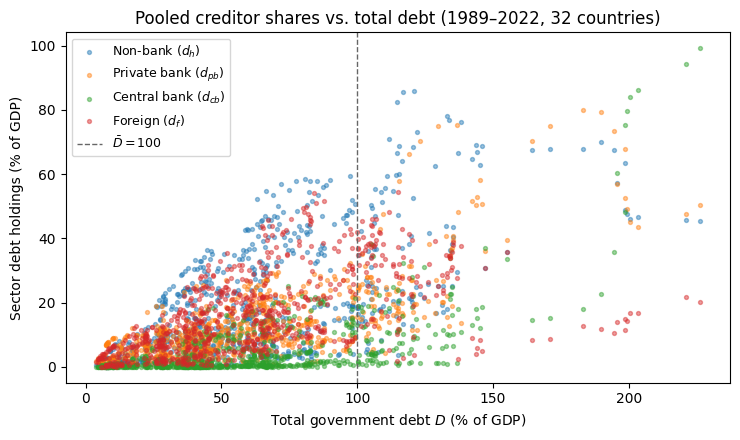

In [2]:
import matplotlib.pyplot as plt

shares = panel.dropna(subset=['d', 'dh', 'dcb', 'dpb', 'df'])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.scatter(shares['d'], shares['dh'],  s=8, alpha=0.45, label='Non-bank ($d_h$)')
ax.scatter(shares['d'], shares['dpb'], s=8, alpha=0.45, label='Private bank ($d_{pb}$)')
ax.scatter(shares['d'], shares['dcb'], s=8, alpha=0.45, label='Central bank ($d_{cb}$)')
ax.scatter(shares['d'], shares['df'],  s=8, alpha=0.45, label='Foreign ($d_f$)')
ax.axvline(100, ls='--', lw=1, color='0.4', label=r'$\bar D = 100$')
ax.set_xlabel('Total government debt $D$ (% of GDP)')
ax.set_ylabel('Sector debt holdings (% of GDP)')
ax.set_title('Pooled creditor shares vs. total debt (1989–2022, 32 countries)')
ax.legend(loc='upper left', fontsize=9)
fig.tight_layout()
plt.show()

## 3. First-stage replication: structural non-bank size

Stage 1 of the empirical strategy (paper eq. (8); see
`Subfiles/Empirical.tex` and `do/threshold_estimation_centered.do`)
regresses sector size on total debt and the centred threshold dummy,
with country and year fixed effects:

$$
s_{ijt}\;=\;\delta_{ij}+\delta_{jt}+\alpha_{1j}\,D_{it}+\alpha_{2j}\,\mathbf{1}\{D_{it}\ge\bar D\}\,(D_{it}-\bar D)+u_{ijt}.
$$

We replicate the non-bank ($s_{h,it}$) row of
`Subfiles/Empirical.tex` Table 1 here using the hand-rolled
within-FE estimator with country-clustered SE in `_common.py`.
Stata reports for the same regression: $\hat\alpha_{1h}=-0.203$
$(0.234)$ and $\hat\alpha_{2h}=-0.184$ $(0.203)$ — see
`Code/empirical_debt_composition/results/threshold_centered_results.txt`.

In [3]:
import numpy as np
from Code.empirical_debt_composition.python._common import xtreg_fe_with_country_fe

df = panel.copy()
df['d_high_c'] = np.where(df['d'].notna() & (df['d'] > 100),
                          df['d'] - 100, 0.0)

# Restrict to the analysis sample BEFORE building year dummies, so that
# we only carry dummies for years that actually appear after dropping
# missing nonbank_size / d. Otherwise the within-transformed design
# matrix is singular (some year dummies become identically zero
# inside the filtered sample).
sample = df.dropna(subset=['nonbank_size', 'd', 'country_id', 'year']).copy()
present_years = sorted(sample['year'].unique())
# Drop the earliest year as the omitted base, matching Stata's i.year
# default in 'xtreg ... i.year, fe'.
year_dummies = present_years[1:]
for y in year_dummies:
    sample[f'y{int(y)}'] = (sample['year'] == y).astype(float)
regs = ['d', 'd_high_c'] + [f'y{int(y)}' for y in year_dummies]

result, _ = xtreg_fe_with_country_fe(
    sample, y_col='nonbank_size', regressors=regs,
    entity_col='country_id', cluster_cols=('country_id',),
)

print('Non-bank size, first-stage centred-threshold spec\n' + '-' * 60)
for name in ['d', 'd_high_c']:
    b = result.coef[name]
    s = result.se[name]
    print(f'  {name:<10s}  coef = {b:+.4f}   SE = {s:.4f}   t = {b/s:+.2f}')
print(f'\n  N = {result.nobs}   within R^2 = {result.centered_r2:.3f}')
print('\nStata reports (committed in threshold_centered_results.txt):')
print('  d           coef = -0.2030   SE = 0.2339   t = -0.87')
print('  d_high_c    coef = -0.1840   SE = 0.2030   t = -0.91')

Non-bank size, first-stage centred-threshold spec
------------------------------------------------------------
  d           coef = -0.2030   SE = 0.2410   t = -0.84
  d_high_c    coef = -0.1840   SE = 0.2092   t = -0.88

  N = 547   within R^2 = 0.918

Stata reports (committed in threshold_centered_results.txt):
  d           coef = -0.2030   SE = 0.2339   t = -0.87
  d_high_c    coef = -0.1840   SE = 0.2030   t = -0.91


## 4. Where to go next

- **Run the full Stata pipeline** (requires Stata 17+):
  `./reproduce.sh --empirical` from the repo root.
- **Run the in-progress Python port** end-to-end:
  see `Code/empirical_debt_composition/python/twoway_cluster_full.py`
  and `…/threshold_default_trim.py`.
- **Read the paper:** `./reproduce.sh --docs` rebuilds
  `emma0502606.pdf` in ~6 seconds on a recent laptop
  (see *Reproduction times* in the top-level `README.md`).

Open issues on the GitHub repository if you find a discrepancy
between the Python and Stata estimates that this notebook does not
already document.